# --------------------------------------------------------------
# Code for Mamba-MPC on the Four Tank Process
# --------------------------------------------------------------
## This notebook includes:
 - Data Generation
 - Training of Mamba-MPC 
 - Closed-loop Mamba-MPC simulation for Reference Tracking vs LSTM-MPC
# --------------------------------------------------------------

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from MambaMPC.pscan import pscan
from MambaMPC.mamba_model import Mamba, MambaConfig
from MambaMPC.DataProcessing import HankelMatrices, HankelMatricesStates, HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates, Sequence2SequenceFuture, Sequence2SequencePast
from MambaMPC.DataProcessing import BestModelSaver
from MambaMPC.plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from MambaMPC.functions import four_tank, multisine
from scipy.integrate import solve_ivp
torch.set_default_dtype(torch.float64)

## Data Generation

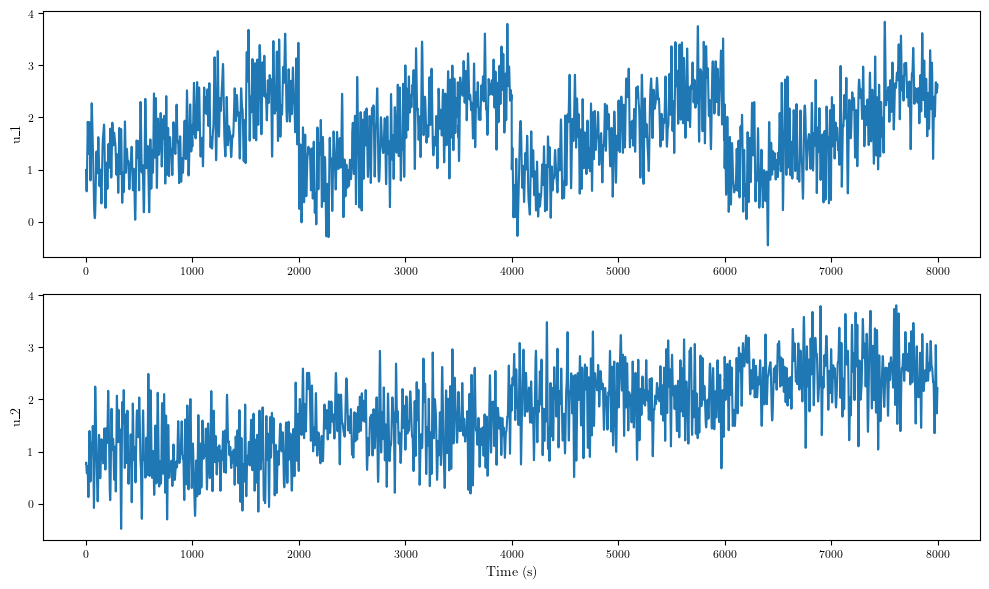

In [14]:
# Generate piecewise constanrt reference for u1
u1_data1 =  np.tile([1.000], (500, 1))
u1_data2 =  np.tile([1.500], (500, 1))
u1_data3 =  np.tile([2.000], (500, 1))
u1_data4 =  np.tile([2.500], (500, 1))

u1_data_all = np.concatenate((u1_data1, u1_data2, u1_data3, u1_data4), axis=0)
u1_data_all = np.concatenate((u1_data_all, u1_data_all, u1_data_all, u1_data_all), axis=0)

# Generate piecewise constanrt reference for u2
u2_data1 =  np.tile([1.000], (2000, 1))
u2_data2 =  np.tile([1.500], (2000, 1))
u2_data3 =  np.tile([2.000], (2000, 1))
u2_data4 =  np.tile([2.500], (2000, 1))
u2_data_all = np.concatenate((u2_data1, u2_data2, u2_data3, u2_data4), axis=0)

# Add multisine to piecewise constant signals
u_data_1_additional = 0.5*multisine(N_points_per_period=8000, N_periods=1, pmin=1, pmax=500, n_crest_factor_optim=100,seed=42)
u_data_2_additional = 0.5*multisine(N_points_per_period=8000, N_periods=1, pmin=1, pmax=500, n_crest_factor_optim=100,seed=36)
u1_data = u1_data_all + u_data_1_additional.reshape(-1, 1)
u2_data = u2_data_all + u_data_2_additional.reshape(-1, 1)
u_data = np.hstack((u1_data,u2_data))

# Plot the final input signal which will be used to generate the data
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(u1_data)
plt.ylabel('u_1')
plt.subplot(2, 1, 2)
plt.plot(u2_data)
plt.ylabel('u_2')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

C:\Users\Michiel\AppData\Local\Temp\ipykernel_91060\1277242690.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u1 = float(u1_data[i])
C:\Users\Michiel\AppData\Local\Temp\ipykernel_91060\1277242690.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u2 = float(u2_data[i])


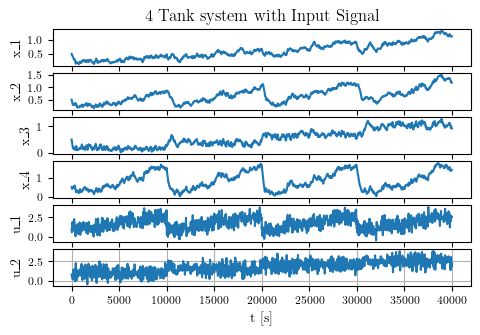

In [15]:
# Model parameters
N = 20 # prediction horizon of the controller
Ts = 5 # Sampling time of the controller
a1, a2, a3, a4 = 1.31e-4, 1.51e-4, 9.27e-5, 8.82e-5
gamma_a, gamma_b = 0.3, 0.4
g, Sc = 9.81, 0.06
params = {'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4, 'gamma_a': gamma_a, 'gamma_b': gamma_b, 'g': g, 'Sc': Sc}

x0 = np.array([0.5, 0.5, 0.5, 0.5])  # Initial conditions: [h1, h2, h3, h4]
t_vec = [0]
x = [x0]

# Main loop
for i in range(len(u1_data)):
    u1 = float(u1_data[i])
    u2 = float(u2_data[i])
    sol = solve_ivp(lambda t, y: four_tank(t, y, u1, u2, params),[0, Ts], x0, method='RK45')
    x0 = sol.y[:, -1]
    x.append(x0)  # store state
    t_vec.append((i+1) * Ts)  # store time

# Convert list to numpy array 
x = np.array(x)
t_vec = np.array(t_vec)


# Plotting
plt.subplot(6,1,1)
plt.plot(t_vec, x[:, 0], label='x_1')
plt.title('4 Tank system with Input Signal')
plt.ylabel('x_1')
plt.subplot(6,1,2)
plt.plot(t_vec, x[:, 1], label='x_2')
plt.ylabel('x_2')
plt.subplot(6,1,3)
plt.plot(t_vec, x[:, 2], label='x_3')
plt.ylabel('x_3')
plt.subplot(6,1,4)
plt.plot(t_vec, x[:, 3], label='x_4')
plt.ylabel('x_4')
plt.subplot(6,1,5)
plt.plot(t_vec[0:len(u1_data)], u1_data, label='u_1')
plt.ylabel('u_1')
plt.subplot(6,1,6)
plt.plot(t_vec[0:len(u2_data)], u2_data, label='u_2')
plt.ylabel('u_2')
plt.xlabel('t [s]')
plt.grid()
plt.show()

In [ ]:
## Save the dataset
filename = "Data/FourTank_MS_8000"
np.save('Data/' + filename + '_u.npy', u_data)
np.save('Data/' + filename + '_x.npy', x)

torch.Size([6500, 2])

In [16]:
#Parameters
N = 20
BatchSize = 128
TestSetSize = 500

#Split the data
u_test = u_data[len(u_data)-TestSetSize:,:]
x_test = x[len(x)-TestSetSize:,:]
u_data = u_data[:len(u_data)-TestSetSize,:]
x_data = x[:len(x)-TestSetSize,:]

u_data = torch.DoubleTensor(u_data)
x_data = torch.DoubleTensor(x_data)
u_test = torch.DoubleTensor(u_test) 
x_test = torch.DoubleTensor(x_test)
print("u_data shape:"+str(u_data.shape))
print("x_data shape:"+str(x_data.shape))


#Training Data
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_data,x_data, N)
X, Y  = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)

#Test Data
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test,x_test, N)
X_test, Y_test = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)

# Use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    X = X.cuda()
    Y = Y.cuda()
    X_test = X_test.cuda()
    Y_test = Y_test.cuda()
    print("Using GPU")

#Construct Dataloader
Dataset = TensorDataset(X, Y)
Dataset_test = TensorDataset(X_test, Y_test)
train = DataLoader(Dataset, batch_size=BatchSize, shuffle=False)
test = DataLoader(Dataset_test, batch_size=BatchSize, shuffle=False)

u_data shape:torch.Size([7500, 2])
x_data shape:torch.Size([7501, 4])
Hankel Matrices Generated
Hankel Matrices Generated
Using GPU


## Training Mamba-MPC

In [19]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 20, d_state = 8, dt_size=2)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 
    

In [ ]:
#Name of File to save the model
filename = "D8_dstate8_Conv20_L1"

#Epochs, Learning Rate and Weight Decay
lr = 1e-3
wd = 1e-5
epochs = 2000
Gamma = 0.998

#Load Model Structure
X_sample,Y_sample = next(iter(train))
batch_size,SequenceLength,Input_dim = X_sample.shape
_,N, Output_dim = Y_sample.shape 
model = MambaMPC(Input_dim, Output_dim)


#Optimizer and Scheduler
opt = torch.optim.AdamW(model.parameters(),lr=lr, weight_decay=wd)

scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=Gamma)

if device == "cuda":
    model = model.cuda()
    print("Using GPU")

Vallosses = []
Train_loss = []

#Initialize Best Model Saver
best_model_saver = BestModelSaver(filepath="State_dicts/" + filename)

for e in range(epochs):
    model.train()
    running_loss = 0.
    last_loss = 0
    for idx,data in enumerate(train):
        
        #Grab Sample        
        X,Y = data

        #Training Step
        opt.zero_grad()
        z = model(X)
        loss =  torch.mean((z.squeeze(0) - Y) ** 2) / torch.mean((Y) ** 2)   #weighted_mse_loss(z.squeeze(0),Y, weight)
        loss.backward()
        opt.step()
        running_loss += loss.item()

        
    model.eval()
    Vloss = 0.0 # Use a float, not a tensor
    with torch.no_grad():
        for idx, data in enumerate(test):

            #Grab Sample
            X_val, Y_val = data

            #Calculate Validation Loss
            y_eval = model(X_val)
            Val_loss = torch.mean((y_eval - Y_val) ** 2) / torch.mean((Y_val) ** 2)            
            Vloss += Val_loss.item()

    
    average_vloss = Vloss / len(test)
    Vallosses.append(average_vloss)
    
    #Update Scheduler
    scheduler.step()

    # print every 10 epoch and save best model
    if e%10 == 0 and e!=0:
        print('Epoch %d | Lossp: %.5f | Validation Loss: %.5f' % (e, running_loss/len(train), average_vloss))
        best_model_saver(current_valid_loss=average_vloss,
                model=model,
                epoch=e, # Current epoch index (0-based)
                optimizer=opt,
                criterion=F.mse_loss)
    Train_loss.append(running_loss/batch_size)

Using GPU
Initialized BestModelSaver. Will save best model to: State_dicts/Test
Epoch 10 | Lossp: 0.14574 | Validation Loss: 0.23777
Validation loss improved from inf to 0.2378.
Epoch 20 | Lossp: 0.03309 | Validation Loss: 0.06351
Validation loss improved from 0.2378 to 0.0635.
Epoch 30 | Lossp: 0.01919 | Validation Loss: 0.04039
Validation loss improved from 0.0635 to 0.0404.
Epoch 40 | Lossp: 0.01102 | Validation Loss: 0.02122
Validation loss improved from 0.0404 to 0.0212.
Epoch 50 | Lossp: 0.00692 | Validation Loss: 0.01219
Validation loss improved from 0.0212 to 0.0122.
Epoch 60 | Lossp: 0.00484 | Validation Loss: 0.00750
Validation loss improved from 0.0122 to 0.0075.


KeyboardInterrupt: 

## Model Validation

In [30]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
#Load Data
u_data = np.load('Data/Four_Tank_u_test.npy')
x_data = np.load('Data/Four_Tank_x_test.npy')

#Prediction Horizon Length
N = 20

#Construct dataset
u_data = torch.DoubleTensor(u_data)
x_data = torch.DoubleTensor(x_data)
#Training Data
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_data,x_data, N)
X, Y  = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)



Hankel Matrices Generated


In [25]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 20, d_state = 8, dt_size=4)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 
    

In [27]:
model = MambaMPC(6,4)
model.load_state_dict(torch.load("State_dicts/ZOH_D8_dstate8_Conv20_dt4_State",map_location=torch.device('cpu'))['model_state_dict'])
model.eval()
mat = model(X)
yhat = mat.detach().numpy()

C:\Users\Michiel\AppData\Local\Temp\ipykernel_91060\670227294.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("State_dicts/ZOH_D8_dstate

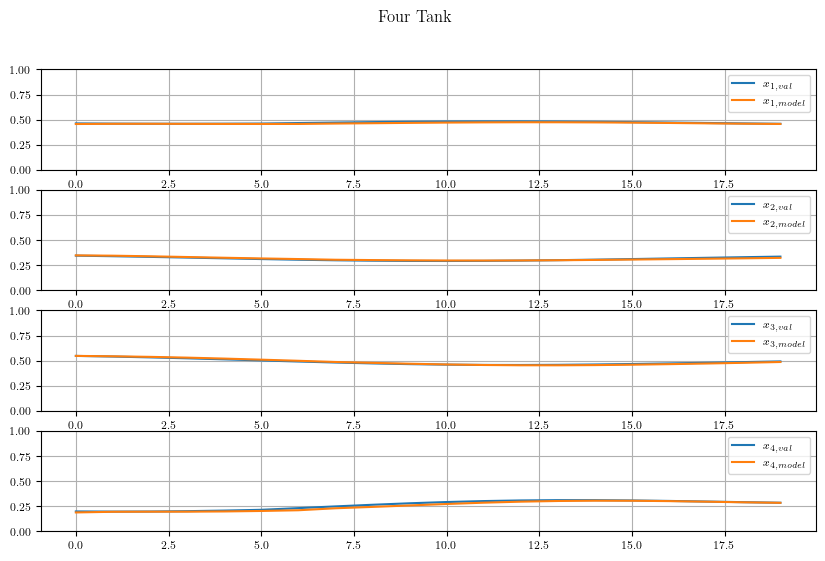

In [ ]:
#Plot the validation results

N_step  = 1
index  = 493

fig, axs = plt.subplots(4, figsize=(10, 6))
fig.suptitle("Four Tank")
axs[0].plot(Y[index ,:,0], label="$x_{1,val}$")
axs[0].plot(yhat[index ,:,0], label = "$x_{1,model}$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(0, 1)

axs[1].plot(Y[index ,:,1], label="$x_{2,val}$")
axs[1].plot(yhat[index ,:,1], label = "$x_{2,model}$")
axs[1].legend()
axs[1].grid()
axs[1].set_ylim(0, 1)


axs[2].plot(Y[index ,:,2], label="$x_{3,val}$")
axs[2].plot(yhat[index ,:,2], label = "$x_{3,model}$")
axs[2].legend()
axs[2].grid()
axs[2].set_ylim(0, 1)

axs[3].plot(Y[index ,:,3], label="$x_{4,val}$")
axs[3].plot(yhat[index ,:,3], label = "$x_{4,model}$")
axs[3].legend()
axs[3].grid()
axs[3].set_ylim(0, 1)

plt.show()


In [41]:
#Calculate Errors
MAE = np.mean(np.mean(np.abs(yhat - Y.numpy()),0),0)
RMAE = np.sqrt(MAE)
NRMAE = RMAE/(np.max(Y.numpy())-np.min(Y.numpy()))

print("MAE: " + str(MAE))
print("RMAE: " + str(RMAE))
print("NRMAE: " + str(NRMAE))

MAE: [0.00462185 0.00712112 0.00791957 0.00912265]
RMAE: [0.06798417 0.0843867  0.08899198 0.09551256]
NRMAE: [0.04314651 0.05355645 0.05647922 0.06061754]


In [32]:
# Calculate R-squared
r2_x1 = r2_score(Y[:,:,0].numpy(), yhat[:,:,0] )
r2_x2 = r2_score(Y[:,:,1].numpy(), yhat[:,:,1] )
r2_x3 = r2_score(Y[:,:,2].numpy(), yhat[:,:,2] )
r2_x4 = r2_score(Y[:,:,3].numpy(), yhat[:,:,3] )


print(f"R-squared on X1: {r2_x1}")
print(f"R-squared on X2: {r2_x2}")
print(f"R-squared on X3: {r2_x3}")
print(f"R-squared on X4: {r2_x4}")

R-squared on X1: 0.996388714919591
R-squared on X2: 0.9974611759525842
R-squared on X3: 0.9843592076320855
R-squared on X4: 0.9974598514124022


## Closed Loop Reference Tracking


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from MambaMPC.mamba_model import Mamba, MambaConfig, MambaContinuous, SimbaContinuous, SimbaConfig
from casadi import *
import casadi as cs
from casadi.tools import *
import time
from MambaMPC.MambaCasadi import CasadiMamba
from scipy.integrate import solve_ivp

In [46]:

class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 20, d_state = 8, dt_size=4)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)
        return x.squeeze(0) 

In [47]:

# Model parameters
a1, a2, a3, a4 = 1.31e-4, 1.51e-4, 9.27e-5, 8.82e-5
gamma_a, gamma_b = 0.3, 0.4
g, Sc = 9.81, 0.06

params = {'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4, 'gamma_a': gamma_a, 'gamma_b': gamma_b, 'g': g, 'Sc': Sc}

# Dynamics function for simulation
def four_tank(t, x, u1, u2, params):
    x1, x2, x3, x4 = x
    a1, a2, a3, a4 = params['a1'], params['a2'], params['a3'], params['a4']
    Sc, gamma_a, gamma_b = params['Sc'], params['gamma_a'], params['gamma_b']
    g = params['g']
    dx1 = (-a1 / Sc) * np.sqrt(max(0, 2 * g * x1)) + (a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + gamma_a / (3600 * Sc) * u1
    dx2 = (-a2 / Sc) * np.sqrt(max(0, 2 * g * x2)) + (a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + gamma_b / (3600 * Sc) * u2
    dx3 = (-a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + (1 - gamma_b) / (3600 * Sc) * u2
    dx4 = (-a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + (1 - gamma_a) / (3600 * Sc) * u1
    return (dx1, dx2, dx3, dx4)

In [50]:

def setup_SPC(nu, nx, N, Q, R, Rd, S):
    """Sets up the SPC controller.

        Args:
        MambaModel: Your system dynamics model (CasADi function).
        n_y: Number of outputs.
        n_u: Number of inputs.
        N: Prediction horizon.
        Tini: Initial state length.
        Q: State tracking cost matrix (n_y x n_y).
        R: Input cost matrix (n_u x n_u).
        Rd: Input rate of change cost matrix (n_u x n_u).
        S: Terminal state cost

    Returns:
        S_spc: The CasADi solver.
        opt_x_num: Numerical instance of optimization variables (for warm-starting).
        opt_p_num: Numerical instance of parameters.
        lbx: Lower bounds on variables.
        ubx: Upper bounds on variables.
    """
    
    # Create optimization variables:
    opt_x = struct_symMX([
        entry('x', shape=(N,nx)),
        entry('u_N', shape=(N,nu))
    ])

    # Create parameters of the optimization problem
    opt_p = struct_symMX([
        entry('ref', shape=(N, nx)),
        entry('u_prev', shape=(1,nu)),
        entry('x1', shape=(1), repeat=1),
        entry('x2', shape=(1), repeat=1),
        entry('x3', shape=(1), repeat=1),
        entry('x4', shape=(1), repeat=1)
    ])

    # Create numerical instances of the structures (holding all zeros as entries)
    opt_x_num = opt_x(0)
    opt_p_num = opt_p(0)

    

    
    # Define the objective function
      # Define the objective function
    obj = 0
    for k in range(N):
        xk = opt_x['x', k,:]
        uk = opt_x['u_N', k,:]

        # State tracking cost
        error_x = xk - cs.vertcat(opt_p['ref',k,:])
        # obj += cs.sum2(cs.sum1(Q_casadi * (error_x**2).T)) # Original - functionally correct but complex
        obj += cs.mtimes([error_x, Q, error_x.T]) # Standard and clear

        # Input cost
        if k == 0:  
            du = opt_x['u_N', k,:] - opt_p['u_prev']
            obj += cs.mtimes([du, Rd, du.T])

        else:
            du = opt_x['u_N', k,:] - opt_x['u_N', k-1,:]
            obj += cs.mtimes([du, Rd, du.T])

    # Terminal state cost
    # obj += cs.sum2(cs.sum1(S * cs.sumsqr(opt_x['x',N-1,:] - cs.vertcat(opt_p['ref'])))) # Correct indexing for terminal cost

    # Create the model
    model = MambaMPC(6,4)
    model.load_state_dict(torch.load("State_dicts/ZOH_D8_dstate8_Conv20_dt4_State", weights_only=True, map_location=torch.device('cpu'))['model_state_dict'])
    
    constraint = []
 
    u1 = opt_x['u_N', :,0]
    u2 = opt_x['u_N', :,1]
    x1 = cs.repmat( *opt_p['x1'], N,1)
    x2  = cs.repmat(*opt_p['x2'], N,1)
    x3  = cs.repmat(*opt_p['x3'], N,1)
    x4  = cs.repmat(*opt_p['x4'], N,1)
    inputs = cs.horzcat(u1,u2, x1, x2, x3, x4)
    
    

    States = model.mamba.layers[0].mixer.A_log.detach().numpy().shape[1]
    dt = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy().shape[1]
    x_model =  CasadiMamba(inputs, model,N,dt,States)

    # Create the constraints
    constraint = cs.vertcat(opt_x['x', :,:] - x_model)
    constraint = cs.reshape(constraint, N*nx, 1)

    # Create lower and upper bound structures and set all values to plus/minus infinity.
    lbx = opt_x(-np.inf)
    ubx = opt_x(np.inf)

    # Set only bounds on u_N
    lbx['u_N'] = 0
    ubx['u_N'] = 4

    # Set bounds on the state
    lbx['x'] = 0
    ubx['x'] = np.inf

    opts = {'ipopt.print_level': 0, 'print_time': 0}
    #opts = {"print_header":False, "print_iteration":False,"print_time":False, "print_in": False, "print_out": False}
    #opts = {'fatrop.print_level': 0, 'print_time': 0}
    # Create Optim
    nlp = {'x': opt_x, 'f':obj, 'g': constraint, 'p': opt_p}
    S_mpc = nlpsol('S', 'ipopt', nlp,opts)
    # S_mpc.generate_dependencies('mpc_solver_fast.c')
    # S_mpc = nlpsol("solver", "sqpmethod", "mpc_solver_fast.dll", opts)
    return S_mpc, opt_x_num, opt_p_num, lbx, ubx

Progress of iteration: 100.0% complete   

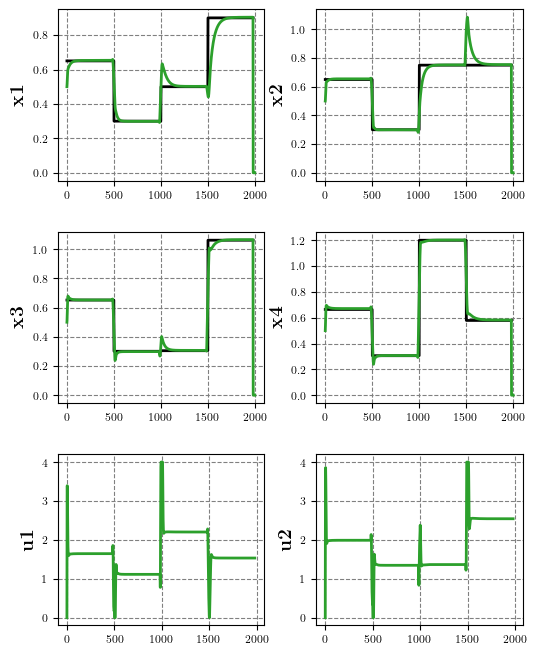

Computation Time:  0.1697227793510514


In [57]:
#Sampling Time
Ts = 5

# Simulation time
time_range = 10

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

#Model Variables
nx = 4  # [theta, theta_dot]
ny = 4  # [theta, theta_dot]
nu = 2  # torque
N = 20
Nny = N*ny

# Define constant pieces
ref1 = np.tile([0.650, 0.650, 0.652, 0.664], (500, 1))
ref2 = np.tile([0.300, 0.300, 0.301, 0.306], (500, 1))
ref3 = np.tile([0.500, 0.750, 0.305, 1.200], (500, 1))
ref4 = np.tile([0.900, 0.750, 1.062, 0.579], (500, 1))

# Concatenate them along the first axis (time steps)
xref_traj = np.concatenate((ref1, ref2,ref3,ref4), axis=0)  # Shape (100, 2)
ksim = xref_traj.shape[0]  # Number of simulation steps


# Initial state
x0 = np.array([0.5, 0.5, 0.5, 0.5])
x = np.zeros((2000, 4))
x[0,:] = np.array([0.5, 0.5, 0.5, 0.5])
u = np.zeros(2000)


# #Controller Variables
Q = np.diag([100, 100, 100, 100])
R = 0 * np.eye(2)  # Input cost matrix
Rd = np.diag([1, 1])
S = 0


uvec1 = [0]
uvec2 = [0]
yvec= x0
y_solver_vec = []
initial_guess = np.zeros((6*N,1))
CompTime = []
CostList = []
S_mpc, opt_x_num, opt_p_num, lbx, ubx = setup_SPC(nu, nx, N, Q, R, Rd, S)

guess_lam_x0 = np.zeros(((nx+nu)*N, 1))
guess_lam_g0 = 0
r = S_mpc(x0 = initial_guess,
        lam_x0 = guess_lam_x0,  # Pass dual guess for x
        lam_g0 = guess_lam_g0,  # Pass dual guess for g
        p=opt_p_num,
        lbg = 0,
        ubg = 0)
opt_x_num.master = r['x']  
uN = np.array(opt_x_num['u_N'])
yN = np.array(opt_x_num['x'])

initial_guess = np.concatenate((uN.reshape(nu*N,1),yN.reshape(nx*N,1))).reshape((nx+nu)*N,1)
guess_lam_x0 = r['lam_x']
guess_lam_g0 = r['lam_g']
uN = np.zeros(N)
yN = np.zeros(N)
uvec1 = [0]
uvec2 = [0]
yvec= x0
guess_lam_x0 = np.zeros(((nx+nu)*N, 1))

# Dual variable guess for general constraints (lbg, ubg)
# We don't know the size yet, so we pass 0 for the very first solve
guess_lam_g0 = 0


for k in range(ksim-N):
 

    # --- Update Data --- 
    opt_p_num['ref'] = np.array(xref_traj[k:k+N, :])
    opt_p_num['u_prev'] = cs.vertcat(uvec1[k], uvec2[k])
    opt_p_num['x1'] = x[k,0]
    opt_p_num['x2'] = x[k,1]
    opt_p_num['x3'] = x[k,2]
    opt_p_num['x4'] = x[k,3]


    

    tic = time.time()
    r = S_mpc(x0 = initial_guess, p=opt_p_num, lbg = 0, ubg = 0, lbx=lbx, ubx=ubx)
    toc = time.time()
    

    CompTime.append(toc - tic)
    opt_x_num.master = r['x'] 
    Cost = r['f'] 
    CostList.append(Cost)
    uN = np.array(opt_x_num['u_N'])
    yN = np.array(opt_x_num['x'])
    initial_guess = np.concatenate((uN.reshape(nu*N,1),yN.reshape(nx*N,1))).reshape((nx+nu)*N,1)

    u1 = opt_x_num['u_N',0,0].full().reshape(-1,1)
    u2 = opt_x_num['u_N',0,1].full().reshape(-1,1)
    uvec1.append(u1.item())
    uvec2.append( u2.item())
    #Four Tank Dynamics 
    #(x[k+1,0], x[k+1,1],x[k+1,2],x[k+1,3]) = four_tank(t, x[k,:], u1.item(), u2.item(), params)
    sol = solve_ivp(lambda t, x: four_tank(t, x, u1.item(), u2.item(), params), [0, Ts], x[k,:])

    # Take the last value as the new initial condition
    (x[k+1,0], x[k+1,1],x[k+1,2],x[k+1,3]) = sol.y[:, -1]
    print(f"\rProgress of iteration: {((k) / (ksim - N-1)) * 100:.1f}% complete   ", end="", flush=True)


fig = plt.figure(figsize=(6, 8)) # Adjust figsize as needed

gs = gridspec.GridSpec(3, 2, figure=fig,hspace=0.3, wspace=0.25) #, height_ratios=[1, 1])

# Create the first subplot (top-left) - occupies row 0, column 0
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(xref_traj[:L-N,0], '-', color = 'k' ,lw=2.0, label="Reference")
ax1.plot(x[:,0],'-',lw=2.0, color = 'tab:green', label = "Mamba-MPC")
ax1.set_ylabel(r"$\mathbf{x1}$", fontsize=14)
ax1.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(xref_traj[:L-N,1], '-', color = 'k' ,lw=2.0, label="Reference")
ax2.plot(x[:,1],'-',lw=2.0, color = 'tab:green', label = "Mamba-MPC")
ax2.set_ylabel(r"$\mathbf{x2}$", fontsize=14)
ax2.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(xref_traj[:L-N,2], '-', color = 'k' ,lw=2.0, label="Reference")
ax3.plot(x[:,2],'-',lw=2.0, color = 'tab:green', label = "Mamba-MPC")
ax3.set_ylabel(r"$\mathbf{x3}$", fontsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(xref_traj[:L-N,3], '-', color = 'k' ,lw=2.0, label="Reference")
ax4.plot(x[:,3],'-',lw=2.0, color = 'tab:green', label = "Mamba-MPC")
ax4.set_ylabel(r"$\mathbf{x4}$", fontsize=14)
ax4.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(uvec1,'-',lw=2.0, color = 'tab:green' ,label = "Mamba-MPC")
ax5.set_ylabel(r"$\mathbf{u1}$", fontsize=14)
ax5.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)


ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(uvec2,'-',lw=2.0, color = 'tab:green' ,label = "Mamba-MPC")
ax6.set_ylabel(r"$\mathbf{u2}$", fontsize=14)
ax6.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

#Show
plt.show()


print("Computation Time: ", np.mean(CompTime))

## LSTM Comparison


In [65]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
import matplotlib.pyplot as plt
from MambaMPC.plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

In [66]:
u1LSTM = np.load("data_LSTM/LSTM_u1_vals.npy", allow_pickle=True)
u2LSTM = np.load("data_LSTM/LSTM_u2_vals.npy", allow_pickle=True)
xLSTM =     np.load("data_LSTM/LSTM_x_vals.npy", allow_pickle=True)

In [67]:
u1Mamba = np.load("data_Mamba/FourTank_MambaMPC_u1.npy", allow_pickle=True)
u2Mamba = np.load("data_Mamba/FourTank_MambaMPC_u2.npy", allow_pickle=True)
xMamba =     np.load("data_Mamba/FourTank_MambaMPC_x.npy", allow_pickle=True)[:1980,:]   

In [68]:
# Define constant pieces
ref1 = np.tile([0.650, 0.650, 0.652, 0.664], (500, 1))
ref2 = np.tile([0.300, 0.300, 0.301, 0.306], (500, 1))
ref3 = np.tile([0.500, 0.750, 0.305, 1.200], (500, 1))
ref4 = np.tile([0.900, 0.750, 1.062, 0.579], (500, 1))

# Concatenate them along the first axis (time steps)
xref_traj = np.concatenate((ref1, ref2, ref3,ref4), axis=0)[:1980,:]  # Shape (100, 2)
ksim = xref_traj.shape[0]  # Number of simulation steps

In [69]:
MAE_LSTM = np.mean(np.abs(xref_traj - xLSTM),axis=0)
MSE_LSTM = mean_squared_error(xref_traj, xLSTM)
print("LSTM MAE:", MAE_LSTM)
print("LSTM MSE:", MSE_LSTM)

LSTM MAE: [0.02942574 0.02634072 0.0191089  0.02053424]
LSTM MSE: 0.002535062438502489


In [70]:
MAE_Mamba = mean_absolute_error(xref_traj, xMamba)
MSE_Mamba = mean_squared_error(xref_traj, xMamba)
print("Mamba MAE:", MAE_Mamba)
print("Mamba MSE:", MSE_Mamba)

Mamba MAE: 0.015616318153438447
Mamba MSE: 0.0023218918758854314


C:\Users\Michiel\AppData\Local\Temp\ipykernel_91060\406847227.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


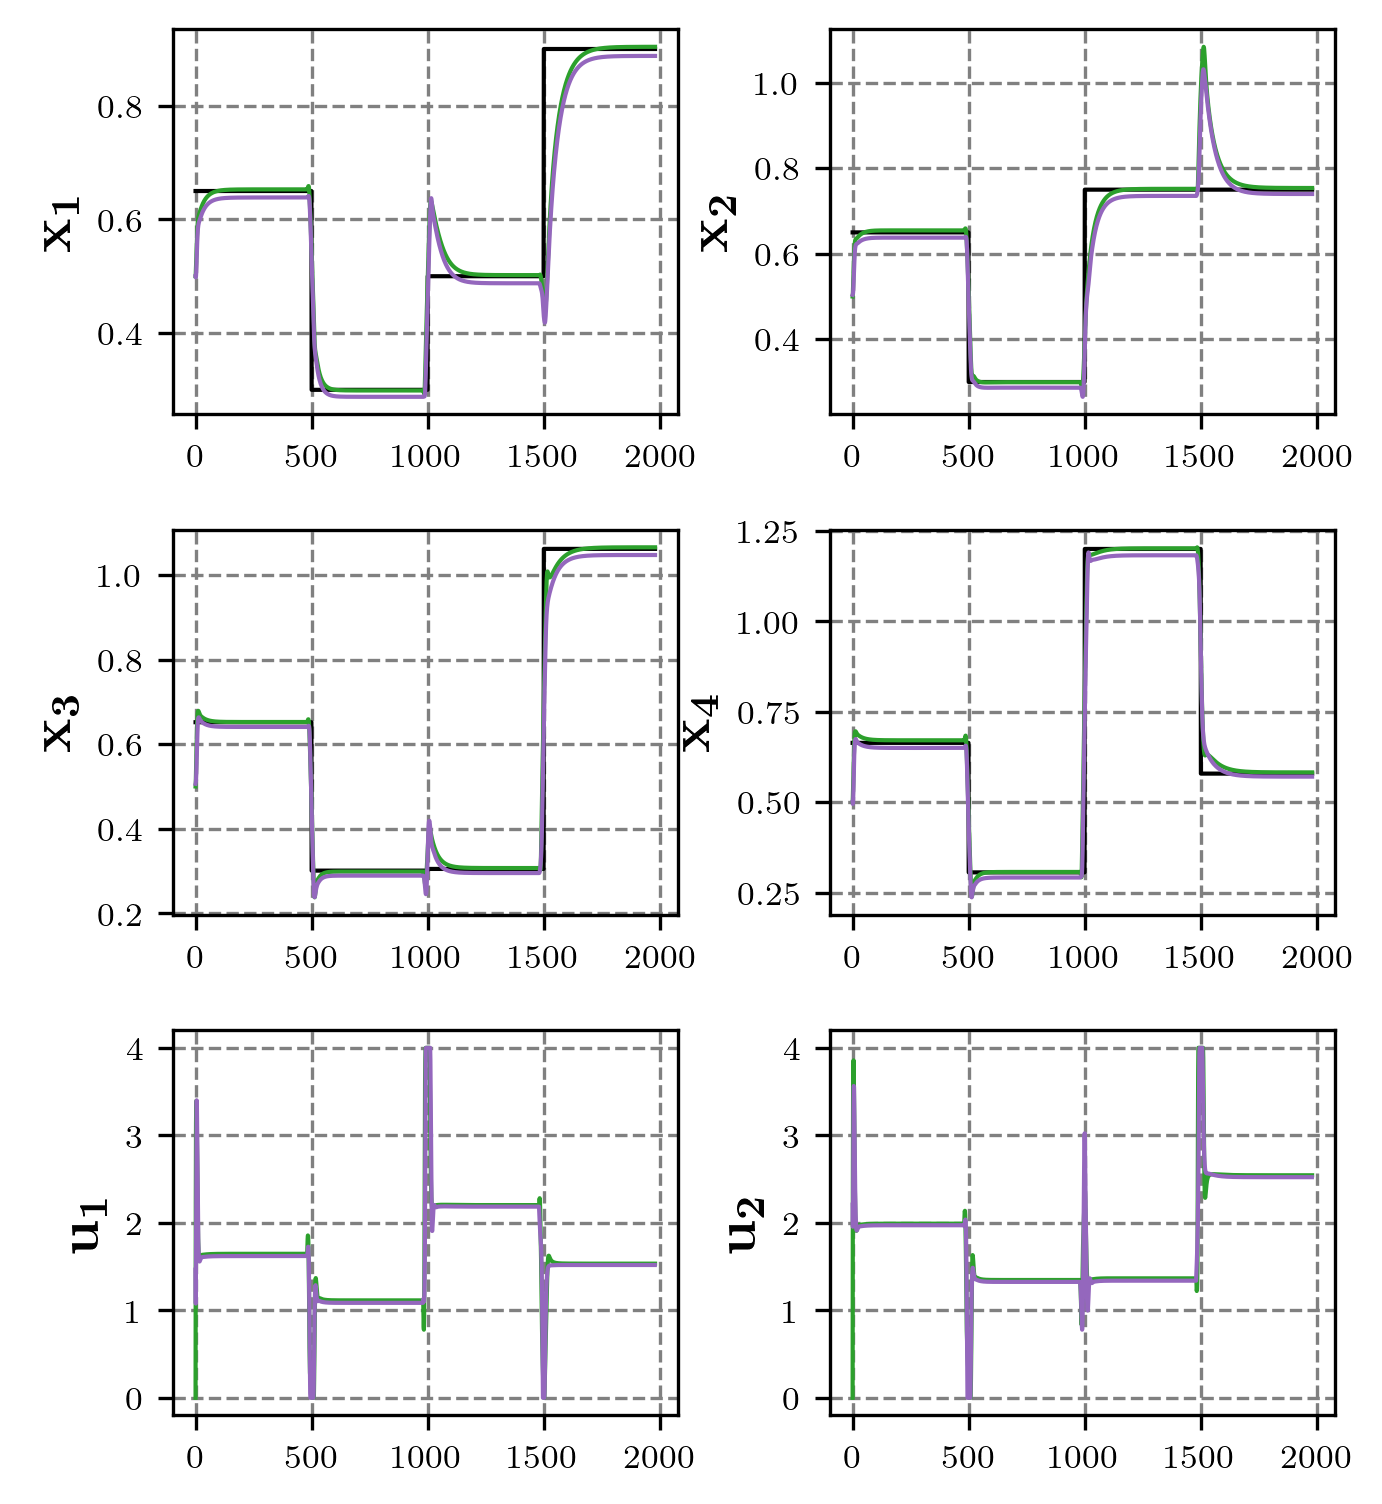

In [75]:

fig = plt.figure(figsize=(5, 6), dpi=300) # Adjust figsize as needed

# Define the grid structure: 2 rows, 2 columns
# We'll use height_ratios to make the bottom plot potentially taller/shorter if desired
gs = gridspec.GridSpec(3, 2, figure=fig,hspace=0.3, wspace=0.3) #, height_ratios=[1, 1])

# Create the first subplot (top-left) - occupies row 0, column 0
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(xref_traj[:,0], '-', color = 'k' ,lw=1.0, label="Reference")
ax1.plot(xMamba[:,0],'-', color = 'tab:green',lw=1.0, label = "Mamba-MPC")
ax1.plot(xLSTM[:,0],'-', color = 'tab:purple',lw=1.0, label = "LSTM-MPC")
ax1.set_ylabel(r"$\mathbf{x_1}$", fontsize=14)
#ax1.legend(loc = 'lower right',fontsize=8)
ax1.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

# Create the second subplot (top-right) - occupies row 0, column 1
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(xref_traj[:,1], '-', color = 'k' ,lw=1.0, label="Reference")
ax2.plot(xMamba[:,1],'-', color = 'tab:green',lw=1.0, label = "Mamba-MPC")
ax2.plot(xLSTM[:,1],'-', color = 'tab:purple',lw=1.0, label = "LSTM-MPC")
ax2.set_ylabel(r"$\mathbf{x_2}$", fontsize=14)
#ax1.legend(loc = 'lower right',fontsize=8)
ax2.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

# Create the second subplot (top-right) - occupies row 0, column 1
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(xref_traj[:,2], '-', color = 'k' ,lw=1.0, label="Reference")
ax3.plot(xMamba[:,2],'-', color = 'tab:green',lw=1.0, label = "Mamba-MPC")
ax3.plot(xLSTM[:,2],'-', color = 'tab:purple',lw=1.0, label = "LSTM-MPC")
ax3.set_ylabel(r"$\mathbf{x_3}$", fontsize=14)
#ax1.legend(loc = 'lower right',fontsize=8)
ax3.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

# Create the second subplot (top-right) - occupies row 0, column 1
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(xref_traj[:,3], '-', color = 'k' ,lw=1.0, label="Reference")
ax4.plot(xMamba[:,3],'-', color = 'tab:green',lw=1.0, label = "Mamba-MPC")
ax4.plot(xLSTM[:,3],'-', color = 'tab:purple',lw=1.0, label = "LSTM-MPC")
ax4.set_ylabel(r"$\mathbf{x_4}$", fontsize=14)
#a1.legend(loc = 'lower right',fontsize=8)
ax4.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(u1Mamba,'-', color = 'tab:green',lw=1.0, label = "Mamba-MPC")
ax5.plot(u1LSTM,'-', color = 'tab:purple',lw=1.0, label = "LSTM-MPC")
ax5.set_ylabel(r"$\mathbf{u_1}$", fontsize=14)
#a1.legend(loc = 'lower right',fontsize=8)
ax5.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)



ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(u2Mamba,'-', color = 'tab:green',lw=1.0, label = "Mamba-MPC")
ax6.plot(u2LSTM,'-', color = 'tab:purple',lw=1.0, label = "LSTM-MPC")
ax6.set_ylabel(r"$\mathbf{u_2}$", fontsize=14)
#a1.legend(loc = 'lower right',fontsize=8)
ax6.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()


# Show the plot
plt.show()
fig.savefig("Figures/VDP_MambaMPC_ReferenceTracking_Paper_LSTM-MPC.png", format='png', dpi=600, bbox_inches='tight', transparent=False)